# TEXAS — Quickstart

**TEXAS** (`texas-psm`) reconstructs sea-surface or thermocline temperature from
GDGT measurements, with full Bayesian uncertainty.

This notebook is the shortest complete path: **measurements → Scaled RI → screening →
temperature**. The default calibration ships inside the package, so no download is
needed and the reconstruction runs offline.

**What you need for your own data**

| Ingredient | Required? | Notes |
|---|---|---|
| GDGT-0, -1, -2, -3, crenarchaeol, crenarchaeol' | **yes** | fractional abundances or peak areas; only ratios matter |
| A temperature prior (`prior_mu_t`, `prior_sigma_t`) | **yes** | a broad prior is fine — 15 ± 10 °C is a reasonable default |
| GDGT-2/GDGT-3 ratio | optional | computed from the same measurements; improves the fit |
| Bottom-water [NO₃⁻], µmol/L | optional | modern climatology or a scenario value |

For the full guide see the [documentation](https://paleolipidrr.github.io/TEXAS/);
a longer worked example lives in `quickstart_extended.ipynb`.

## Step 1 — Install

On Colab, run both cells (CmdStan takes ~5–10 min and must be re-run each session).
Skip them if you already have a working local environment.

In [1]:
# Colab only -- uncomment to run.
# !pip install -q texas-psm
# import cmdstanpy; cmdstanpy.install_cmdstan(version="2.36.0", progress=True)

# Locally, `texas-install-cmdstan` does the same job, and `texas-doctor`
# reports on the whole toolchain if anything fails.

In [2]:
import numpy as np
import pandas as pd
import TEXAS

print("TEXAS", TEXAS.__version__)

TEXAS 0.3.0


/home/rrattan/Documents/GitHub/TEXAS/src/TEXAS/plotting/residual_maps.py:57: UserWarning: `natural_earth_v5_0_0.ocean_basins_50` does not quite extend to 180°E - it's recommended to use `natural_earth_v5_1_2.ocean_basins_50` instead. See https://github.com/regionmask/regionmask/issues/410.
  _OCEAN_BASINS_50 = regionmask.defined_regions.natural_earth_v5_0_0.ocean_basins_50


## Step 2 — Your data

Replace this frame with your own measurements. The six GDGT columns are what
matter; `gdgt23ratio` and `no3` are optional but recommended.

In [3]:
# Example: eight samples down a core. Values are fractional abundances.
df = pd.DataFrame({
    "gdgt0":       [0.42, 0.40, 0.38, 0.35, 0.33, 0.31, 0.29, 0.28],
    "gdgt1":       [0.11, 0.11, 0.12, 0.12, 0.13, 0.13, 0.14, 0.14],
    "gdgt2":       [0.09, 0.10, 0.11, 0.12, 0.13, 0.14, 0.15, 0.16],
    "gdgt3":       [0.02, 0.02, 0.03, 0.03, 0.03, 0.04, 0.04, 0.04],
    "cren":        [0.34, 0.35, 0.34, 0.36, 0.36, 0.36, 0.36, 0.36],
    "cren_prime":  [0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02, 0.02],
    "no3":         [2.3,  2.3,  2.2,  2.1,  2.0,  2.0,  1.9,  1.9],
})
df["gdgt23ratio"] = df["gdgt2"] / df["gdgt3"]
df.head()

,gdgt0,gdgt1,gdgt2,gdgt3,cren,cren_prime,no3,gdgt23ratio
0,0.42,0.11,0.09,0.02,0.34,0.02,2.3,4.500000
1,0.40,0.11,0.10,0.02,0.35,0.02,2.3,5.000000
2,0.38,0.12,0.11,0.03,0.34,0.02,2.2,3.666667
3,0.35,0.12,0.12,0.03,0.36,0.02,2.1,4.000000
4,0.33,0.13,0.13,0.03,0.36,0.02,2.0,4.333333


## Step 3 — Compute the Scaled Ring Index

`cren_weight=3` is the convention used throughout the TEXAS calibration
(crenarchaeol counted as three rings).

In [4]:
df["scaledRI_cren3"] = TEXAS.compute_scaledRI(
    gdgt0=df["gdgt0"], gdgt1=df["gdgt1"], gdgt2=df["gdgt2"],
    gdgt3=df["gdgt3"], cren=df["cren"], cren_prime=df["cren_prime"],
    cren_weight=3,
)

# TEX86 is only needed for screening in the next step.
df["TEX86"] = ((df["gdgt2"] + df["gdgt3"] + df["cren_prime"])
               / (df["gdgt1"] + df["gdgt2"] + df["gdgt3"] + df["cren_prime"]))
df[["scaledRI_cren3", "TEX86"]].round(3)

,scaledRI_cren3,TEX86
0,0.477,0.542
1,0.493,0.560
2,0.503,0.571
3,0.530,0.586
4,0.540,0.581
5,0.557,0.606
6,0.567,0.600
7,0.573,0.611


## Step 4 — Screen the record *(recommended)*

Samples outside the TEX₈₆–Scaled RI domain the calibration was trained on are
extrapolations. The ellipse is a fixed property of the published calibration,
so nothing needs fitting. Flag them and interpret with caution — do not automatically
delete them: past assemblages may genuinely lack a modern analogue.

In [ ]:
from TEXAS.data import MahalanobisOutlierDetector

# No fitting: the detector screens against TEXAS's published calibration
# domain -- the reference ellipse of Section 5.1. Do NOT fit on your own
# record, or the domain moves with the data and unusual records flag less.
detector = MahalanobisOutlierDetector(["TEX86", "scaledRI_cren3"], confidence=0.90)
df["flagged"] = detector.detect_outliers(df)

print(f"{int(df['flagged'].sum())} of {len(df)} samples flagged as outside the calibration domain")

## Step 5 — Reconstruct temperature

Omitting `fwd_posterior` selects the bundled default: the full multivariate
T₀-shift calibration. Nothing is downloaded, and nothing is written to disk
unless you pass `save_results=True`.

Pass `temptype="thermoT"` instead for the thermocline-integrated calibration.

In [6]:
result = TEXAS.predict_T_from_proxyObs(
    proxyObs=df["scaledRI_cren3"].values,
    prior_mu_t=15.0,          # your prior mean temperature, degC
    prior_sigma_t=10.0,       # deliberately broad
    gdgt23ratio=df["gdgt23ratio"].values,   # optional
    no3=df["no3"].values,                   # optional
)

📚 No fwd_posterior given — using the default SST calibration 'tx.GHEB.sst.sri03.G23-N1p0' (full multivariate, G23 + NO3).


/home/rrattan/Documents/GitHub/TEXAS/src/TEXAS/stan/invT.py:481: RuntimeWarning: Stan model 'invT_gen_logi_fixed_multiv_marginal_unconstrained_t0shift' was compiled for a different environment (e.g. Docker or another OS) and cannot run here (exit code 127). The old binary has been removed and the model will be recompiled for your current setup — this is normal when switching between Docker and a local install.
  post_ds = get_invT_posterior(
12:08:37 - cmdstanpy - INFO - compiling stan file /home/rrattan/.texas/stan_cache/invT_gen_logi_fixed_multiv_marginal_unconstrained_t0shift.stan to exe file /home/rrattan/.texas/stan_cache/invT_gen_logi_fixed_multiv_marginal_unconstrained_t0shift


⚙️  Auto M=500 (4000 posterior draws available; approx. error ≈ 4.5%). Override with InvTConfig(n_draws=...).
💡 Using no3_cutoff from forward posterior attributes: 1.0
🔧 Automatically selected Stan file: invT_gen_logi_fixed_multiv_marginal_unconstrained_t0shift.stan
⚙️  Auto CPU config: 4 parallel chains, 2 threads/chain (reduce_sum model)
| M=500 N=8
🔧 Compiling Stan model: invT_gen_logi_fixed_multiv_marginal_unconstrained_t0shift.stan
   (build dir: /home/rrattan/.texas/stan_cache)


12:08:54 - cmdstanpy - INFO - compiled model executable: /home/rrattan/.texas/stan_cache/invT_gen_logi_fixed_multiv_marginal_unconstrained_t0shift


12:08:54 - cmdstanpy - INFO - CmdStan start processing


...

chain 2:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

chain 3:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

chain 4:   0%|          | 0/1500 [00:00<?, ?it/s, (Warmup)]

12:09:01 - cmdstanpy - INFO - CmdStan done processing.



✅ Stan sampling completed successfully


## Step 6 — Read the results

`p50` is the median reconstruction; `p16`–`p84` is the 68 % credible interval,
which includes the residual noise, not just uncertainty in the fitted curve.

In [7]:
out = pd.DataFrame({
    "scaledRI": df["scaledRI_cren3"].round(3),
    "T_p16":    np.round(result["p16"], 2),
    "T_p50":    np.round(result["p50"], 2),
    "T_p84":    np.round(result["p84"], 2),
    "flagged":  df["flagged"],
})
out

,scaledRI,T_p16,T_p50,T_p84,flagged
0,0.477,1.33,7.79,12.84,False
1,0.493,3.47,9.65,14.54,False
2,0.503,4.30,10.24,14.94,False
3,0.530,7.81,13.16,17.34,False
4,0.540,9.22,14.42,18.33,False
5,0.557,11.24,15.71,19.14,False
6,0.567,12.42,16.83,20.15,False
7,0.573,13.40,17.62,20.88,False


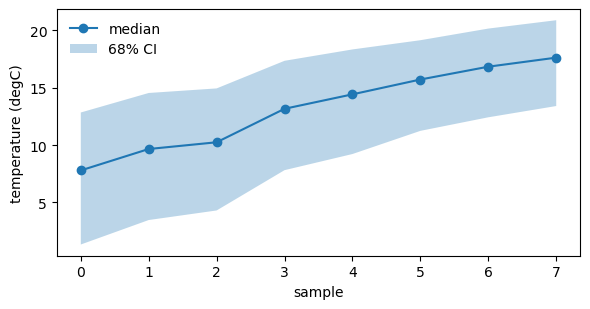

In [8]:
import matplotlib.pyplot as plt

x = np.arange(len(out))
fig, ax = plt.subplots(figsize=(6, 3.2))
ax.fill_between(x, result["p16"], result["p84"], alpha=0.3, label="68% CI")
ax.plot(x, result["p50"], "o-", label="median")
ax.set_xlabel("sample")
ax.set_ylabel("temperature (degC)")
ax.legend(frameon=False)
fig.tight_layout()

## Where to go next

- **Other calibrations** — `TEXAS.download_posteriors(["tx.GHPU.sst.sri03.p0"])`
  fetches the temperature-only fit; `TEXAS.list_posteriors()` shows what you hold.
- **No nitrate data?** Run paired scenarios rather than guessing a single value —
  see Appendix C2.3 of the paper.
- **A longer walkthrough** with a published down-core record and a comparison
  against existing calibrations: `quickstart_extended.ipynb`.
- **Full documentation, guides and an interactive tutorial**:
  <https://paleolipidrr.github.io/TEXAS/>